# Optuna: inteligentne szukanie hiperparametrow

Trenujesz model i masz do wyboru dziesiątki kombinacji parametrów.
Jak znaleźć tę najlepszą bez marnowania czasu?

## Ciemny pokoj z pokretlami

Wyobraź sobie że stoisz w ciemnym pokoju pełnym pokręteł.
Chcesz ustawić je tak, żeby żarówka świeciła jak najjaśniej.

- Pokrętło `max_depth`: zakresy 2–15
- Pokrętło `learning_rate`: zakresy 0.001–0.3
- Pokrętło `n_estimators`: zakresy 50–600
- ... i kilka innych

Ile kombinacji do sprawdzenia? Tysiące. Masz trzy strategie:

| Strategia | Jak dziala | Wada |
|---|---|---|
| Recznie | Krecisz pokretłami "na czuja" | Zalezy od intuicji, wolno |
| Grid Search | Sprawdza KAZDA kombinacje po kolei | Klatwa wymiarowosci: 5 param x 10 wartosci = 100 000 prob |
| Random Search | Losuje kombinacje | Szepty slepy - nie uczy sie z poprzednich wynikow |
| **Optuna** | Uczy sie gdzie jest "jasno" i tam szuka | - |

Ten notebook pokazuje jak dziala Optuna na konkretnym przykladzie.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Syntetyczny dataset klasyfikacji binarnej
X, y = make_classification(
    n_samples=5000, n_features=20, n_informative=10,
    n_redundant=5, flip_y=0.05, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Klasa 1 w train: {y_train.mean():.2%}")

Train: (4000, 20)  |  Test: (1000, 20)
Klasa 1 w train: 49.55%


## Punkt startowy: domyslne parametry XGBoost

Zanim zaczniemy szukac - sprawdzamy co daje model "z pudełka".
To nasz baseline do pobicia.

In [2]:
model_default = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric="auc")
model_default.fit(X_train, y_train)
auc_default = roc_auc_score(y_test, model_default.predict_proba(X_test)[:, 1])
print(f"Domyslne parametry  AUC: {auc_default:.4f}")

Domyslne parametry  AUC: 0.9652


## Random Search: slepec w ciemnym pokoju

Losuje kombinacje parametrow. Nie pamieta co juz sprobowal.
Kazda proba jest niezalezna - brak uczenia sie z historii.

In [3]:
N_TRIALS = 30
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import time

param_dist = {
    "n_estimators":  randint(50, 400),
    "max_depth":     randint(2, 10),
    "learning_rate": uniform(0.01, 0.29),
    "subsample":     uniform(0.5, 0.5),
}

t0 = time.time()
rs = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric="auc"),
    param_dist, n_iter=N_TRIALS, cv=3, scoring="roc_auc", random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)
t_rs = time.time() - t0

best_rs = xgb.XGBClassifier(**rs.best_params_, random_state=42, n_jobs=-1, eval_metric="auc")
best_rs.fit(X_train, y_train)
auc_rs = roc_auc_score(y_test, best_rs.predict_proba(X_test)[:, 1])

print(f"Random Search (30 prob)  AUC: {auc_rs:.4f}  czas: {t_rs:.0f}s")
print(f"Najlepsze parametry: {rs.best_params_}")

Random Search (30 prob)  AUC: 0.9691  czas: 19s
Najlepsze parametry: {'learning_rate': 0.10018487329754203, 'max_depth': 9, 'n_estimators': 342, 'subsample': 0.864803089169032}


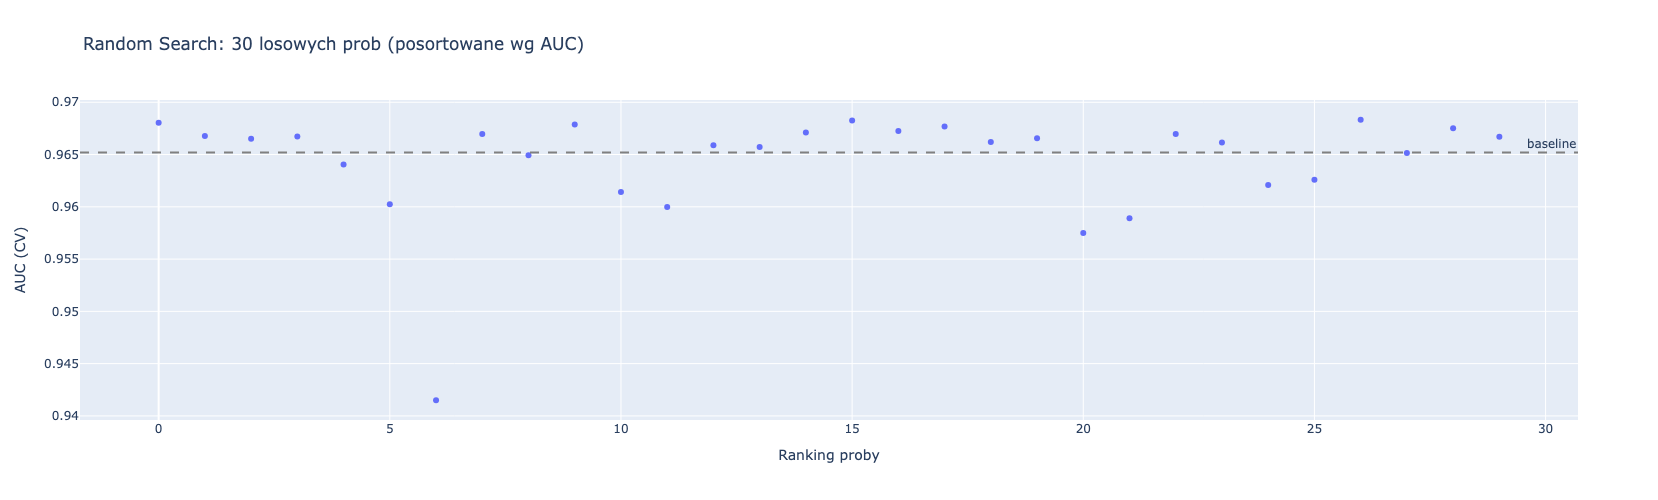

In [22]:
# Wizualizacja: wyniki wszystkich 30 prob Random Search
df_rs_results = pd.DataFrame(rs.cv_results_)
df_rs_results = df_rs_results.reset_index(drop=True)

fig = go.Figure(go.Scatter(
    x=df_rs_results.index, y=df_rs_results["mean_test_score"],
    mode="markers",
    text=[f"n_est={r['n_estimators']}, depth={r['max_depth']}, lr={r['learning_rate']:.3f}"
          for r in df_rs_results["params"]],
    hovertemplate="%{text}<br>AUC=%{y:.4f}",
))
fig.add_hline(y=auc_default, line_dash="dash", line_color="gray",
              annotation_text="baseline")
fig.update_layout(title=f"Random Search: {N_TRIALS} losowych prob (posortowane wg AUC)",
                  xaxis_title="Ranking proby", yaxis_title="AUC (CV)",
                  height=500)
fig.show()


## Optuna

Optuna po kazdej probie aktualizuje swoj model prawdopodobienstwa:
- "Jakie wartosci parametrow dawaly dobre wyniki do tej pory?"
- Kolejna proba bierze wartosci z obszarow, ktore **wygladaly obiecujaco**

### 2 kroki Optuny

**Krok 1: definicja przestrzeni** - mowisz Optunie co moze zmienic i w jakim zakresie  
**Krok 2: optymalizacja TPE** - kilka losowych prob, potem coraz madrzejsze propozycje  


In [14]:
def objective(trial):
    # Krok 1: definicja przestrzeni poszukiwan
    # trial.suggest_* mowi Optunie: "krecisz tym pokretlem w tym zakresie"
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 50, 400),
        "max_depth":        trial.suggest_int("max_depth", 2, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 0.5)
    }

    # Krok 2: trening i ocena
    model = xgb.XGBClassifier(
        **params, random_state=42, n_jobs=-1,
        objective="binary:logistic", eval_metric="auc"
    )
    # cross_val_score zamiast pojedynczego fit - bardziej wiarygodna ocena
    scores = cross_val_score(model, X_train, y_train,
                             cv=3, scoring="roc_auc", n_jobs=-1)
    return scores.mean()


t0 = time.time()
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=N_TRIALS)
t_opt = time.time() - t0

best_opt = xgb.XGBClassifier(
    **study.best_params, random_state=42, n_jobs=-1,
    objective="binary:logistic", eval_metric="auc"
)
best_opt.fit(X_train, y_train)
auc_opt = roc_auc_score(y_test, best_opt.predict_proba(X_test)[:, 1])

print(f"Optuna ({N_TRIALS} prob)  AUC: {auc_opt:.4f}  czas: {t_opt:.0f}s")
print(f"Najlepsze parametry: {study.best_params}")

Optuna (30 prob)  AUC: 0.9679  czas: 42s
Najlepsze parametry: {'n_estimators': 269, 'max_depth': 10, 'learning_rate': 0.031227201869348818, 'subsample': 0.5}


### Jak TPE sie uczy: historia prob

Na wykresie widac klucowa roznice miedzy Random Search a Optuna.
W Random Search wyniki rozkladaja sie losowo przez caly czas.
W Optunie po kilku poczatkowych losowych probach wyniki zaczynaja rosnac - TPE
skupia sie coraz bardziej na obiecujacych obszarach.

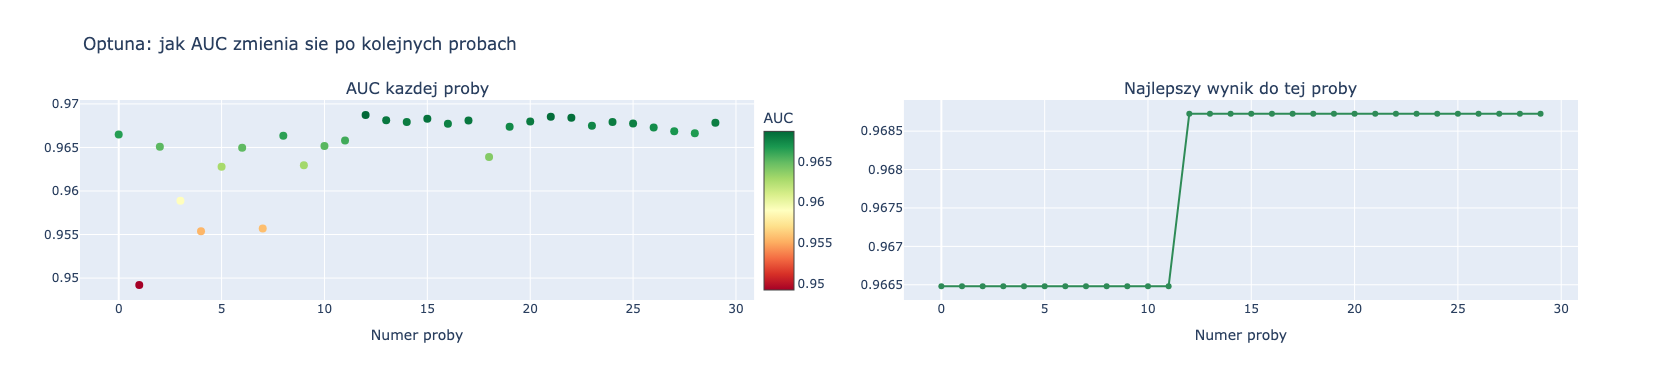

Zielone punkty to dobre proby. TPE z czasem generuje ich coraz wiecej.


In [15]:
trial_values  = [t.value for t in study.trials]
best_so_far   = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["AUC kazdej proby", "Najlepszy wynik do tej proby"])

fig.add_trace(go.Scatter(
    x=list(range(len(trial_values))), y=trial_values,
    mode="markers", marker=dict(
        color=trial_values, colorscale="RdYlGn", size=8, showscale=True,
        colorbar=dict(title="AUC", x=0.45)
    ), name="proba",
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=list(range(len(best_so_far))), y=best_so_far,
    mode="lines+markers", line=dict(color="seagreen", width=2),
    name="najlepszy dotad",
), row=1, col=2)

fig.update_xaxes(title_text="Numer proby")
fig.update_layout(height=380, showlegend=False,
                  title="Optuna: jak AUC zmienia sie po kolejnych probach")
fig.show()

print("Zielone punkty to dobre proby. TPE z czasem generuje ich coraz wiecej.")

### Waznosc parametrow: co tak naprawde ma znaczenie?

Optuna potrafi ocenic, ktore parametry najbardziej wplywaly na wynik.
Parametr z wysoka waznoscia = warto poswiecic mu wiecej uwagi przy tuningu.

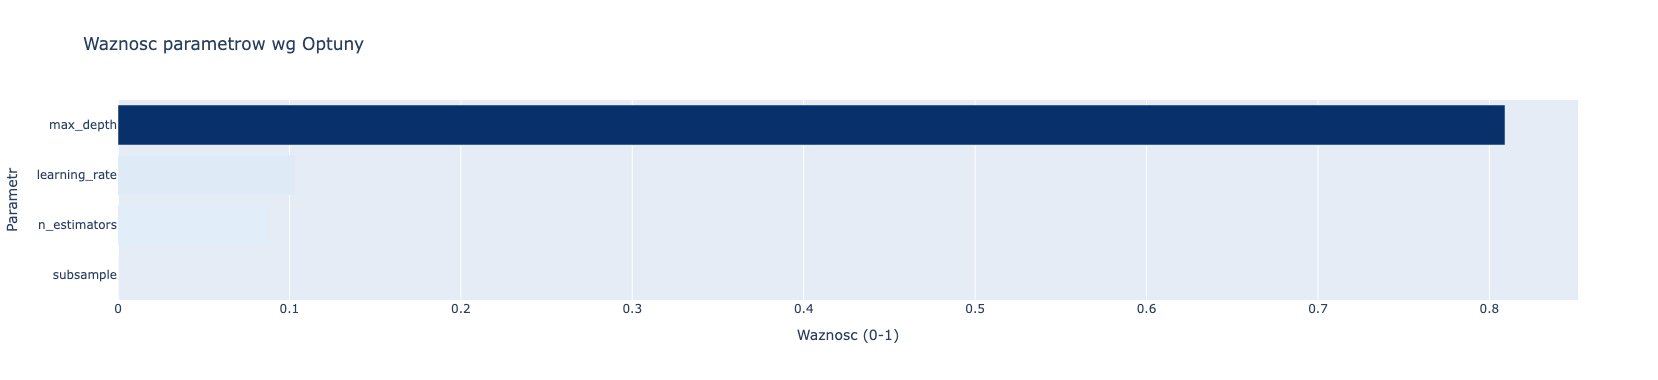

Parametr z najwyzsza waznoscia:
  max_depth: 0.809


In [16]:
importances = optuna.importance.get_param_importances(study)

df_imp = pd.Series(importances).sort_values()
fig = px.bar(x=df_imp.values, y=df_imp.index, orientation="h",
             title="Waznosc parametrow wg Optuny",
             labels={"x": "Waznosc (0-1)", "y": "Parametr"},
             color=df_imp.values, color_continuous_scale="Blues")
fig.update_layout(height=380, coloraxis_showscale=False)
fig.show()

print("Parametr z najwyzsza waznoscia:")
print(f"  {max(importances, key=importances.get)}: {max(importances.values()):.3f}")

## Porownanie: Baseline vs Random Search vs Optuna

                         AUC Czas (s) Prob
Metoda                                    
Domyslne parametry  0.965193        -    -
Random Search       0.969057       19   30
Optuna (TPE)        0.967869       42   30


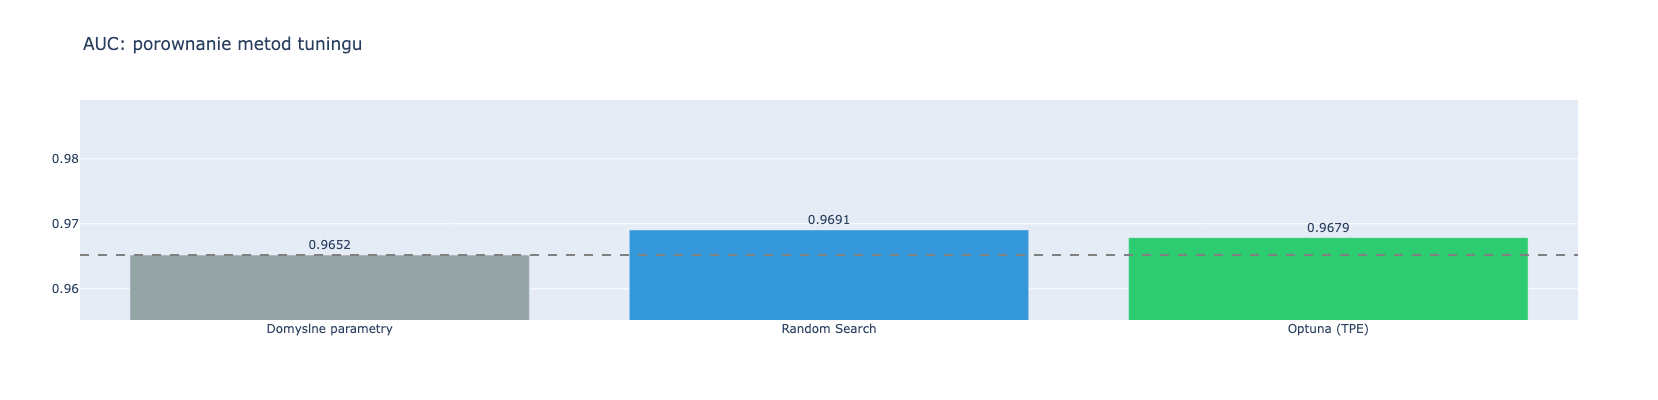

In [17]:
df_comparison = pd.DataFrame([
    {"Metoda": "Domyslne parametry", "AUC": auc_default, "Czas (s)": "-",         "Prob": "-"},
    {"Metoda": "Random Search",      "AUC": auc_rs,      "Czas (s)": f"{t_rs:.0f}",   "Prob": N_TRIALS},
    {"Metoda": "Optuna (TPE)",       "AUC": auc_opt,     "Czas (s)": f"{t_opt:.0f}",  "Prob": N_TRIALS},
]).set_index("Metoda")

print(df_comparison.to_string())

fig = go.Figure(go.Bar(
    x=df_comparison.index,
    y=df_comparison["AUC"],
    marker_color=["#95a5a6", "#3498db", "#2ecc71", "#27ae60"],
    text=[f"{v:.4f}" for v in df_comparison["AUC"]],
    textposition="outside",
))
fig.add_hline(y=auc_default, line_dash="dash", line_color="gray")
fig.update_layout(title="AUC: porownanie metod tuningu",
                  yaxis_range=[df_comparison["AUC"].min() - 0.01, df_comparison["AUC"].max() + 0.02],
                  height=400)
fig.show()

## Praktyczne wskazowki

**Ile prob?**
- 30–50 prob: dobry start dla wiekszosci problemow
- 100+ prob: gdy masz czas i chcesz wycisnac maksimum
- Zasada: im wiecej parametrow w przestrzeni, tym wiecej prob potrzebujesz

**Kiedy uzywac Optuny zamiast Random Search?**
- Gdy tuning trwa dluzej niz 5 minut - Optuna zwroci sie szybciej
- Gdy masz 4+ parametrow do tuningu
- Gdy chcesz miec wykres historii i waznosci parametrow

**Kiedy pruning ma sens?**
- Gdy pojedyncza proba trwa dluzej niz 30 sekund (sieci neuronowe, duze drzewa)
- XGBoost na malych danych: pruning moze nie pomoc (zbyt szybki trening)

**Przestrzen poszukiwan:**
- `suggest_int(name, low, high)` - liczba calkowita
- `suggest_float(name, low, high, log=True)` - liczba zmiennoprzecinkowa, log=True gdy zakres roznic sie o rzedy wielkosci (np. lr: 0.001–0.3)
- `suggest_categorical(name, choices)` - lista wartosci do wyboru